In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/intership implement/archive.zip"
extract_path = "/content/dataset"

# Create folder
os.makedirs(extract_path, exist_ok=True)

# Extract zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Done ✅")

Extraction Done ✅


In [ ]:
os.listdir(extract_path)


['training.1600000.processed.noemoticon.csv']

In [ ]:
import pandas as pd

file_path = "/content/dataset/training.1600000.processed.noemoticon.csv"

# Add correct column names
columns = ['Sentiment', 'ID', 'Date', 'Query', 'User', 'Text']

df = pd.read_csv(file_path, encoding='latin-1', names=columns)

# Show first rows
df.head()

,Sentiment,ID,Date,Query,User,Text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
df.shape
df['Sentiment'].value_counts()


,count
Sentiment,
0,800000
4,800000


In [ ]:
# Map sentiment values
df['Sentiment'] = df['Sentiment'].map({0: 'Negative', 4: 'Positive'})

# Check again
df['Sentiment'].value_counts()

,count
Sentiment,
Negative,800000
Positive,800000


In [ ]:
df[['Text', 'Sentiment']].head()

,Text,Sentiment
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",Negative
1,is upset that he can't update his Facebook by ...,Negative
2,@Kenichan I dived many times for the ball. Man...,Negative
3,my whole body feels itchy and like its on fire,Negative
4,"@nationwideclass no, it's not behaving at all....",Negative


In [ ]:
# Take balanced samples
df_sampled = df.groupby('Sentiment').sample(n=25000, random_state=42)

# Shuffle dataset
df_sampled = df_sampled.sample(frac=1).reset_index(drop=True)

# Check result
df_sampled['Sentiment'].value_counts()

,count
Sentiment,
Positive,25000
Negative,25000


In [ ]:
df_sampled.shape

(50000, 6)

In [ ]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 72.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
df_sampled = df.groupby('Sentiment').sample(n=25000, random_state=42)
df_sampled = df_sampled.sample(frac=1).reset_index(drop=True)

In [ ]:
import spacy
nlp = spacy.load('en_core_web_sm')

In [ ]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    doc = nlp(text.lower())
    tokens = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]

    return ' '.join(tokens)

df_sampled['Cleaned_Text'] = df_sampled['Text'].apply(preprocess_text)

In [ ]:
df_sampled[['Text', 'Cleaned_Text']].head()

,Text,Cleaned_Text
0,I finished drawing the street. Came out really...,finish draw street come niceee
1,Daisy is dead http://apps.facebook.com/dogboo...,daisy dead
2,"Last 4 rides have used up 9053 calories, accor...",ride calorie accord mean room curry week mum a...
3,2 dayz away from June 2nd which is my 22nd Bir...,dayz away june birthday u wonder y like
4,@Trapes oh don't you have anyone that could ...,oh dog sit


/tmp/ipykernel_11885/2560530970.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sampled, x='Sentiment', palette='coolwarm')


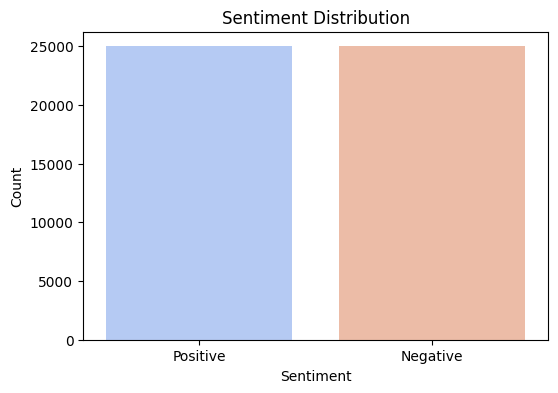

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df_sampled, x='Sentiment', palette='coolwarm')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')

plt.show()

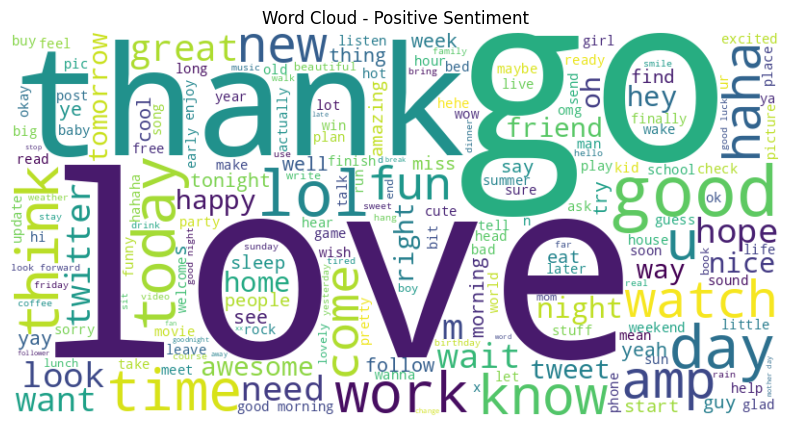

In [ ]:
from wordcloud import WordCloud

# Combine all positive text
positive_text = ' '.join(df_sampled[df_sampled['Sentiment'] == 'Positive']['Cleaned_Text'])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

# Plot
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Sentiment')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df_sampled['Cleaned_Text']
y = df_sampled['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [ ]:
y_pred = nb_model.predict(X_test_tfidf)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100)

Accuracy: 73.04


In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr * 100)

Logistic Regression Accuracy: 74.49


In [ ]:
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", accuracy_svm * 100)

SVM Accuracy: 74.28


In [ ]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=20000,   # increase features
    ngram_range=(1,2)     # include bigrams
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, C=2)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Improved Logistic Regression:", accuracy_lr * 100)

Improved Logistic Regression: 74.27


In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Improved SVM:", accuracy_svm * 100)

Improved SVM: 72.33000000000001


In [ ]:
from sklearn.model_selection import train_test_split

X = df_sampled['Text']   # IMPORTANT CHANGE
y = df_sampled['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2)
)

In [ ]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression:", accuracy_score(y_test, y_pred_lr) * 100)

Logistic Regression: 78.57


In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("SVM:", accuracy_score(y_test, y_pred_svm) * 100)

SVM: 77.60000000000001


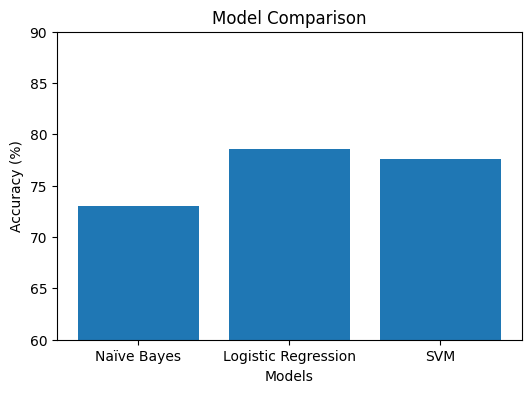

In [ ]:
import matplotlib.pyplot as plt

models = ['Naïve Bayes', 'Logistic Regression', 'SVM']
accuracies = [73.04, 78.57, 77.60]  # use your values

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison')

plt.ylim(60, 90)
plt.show()

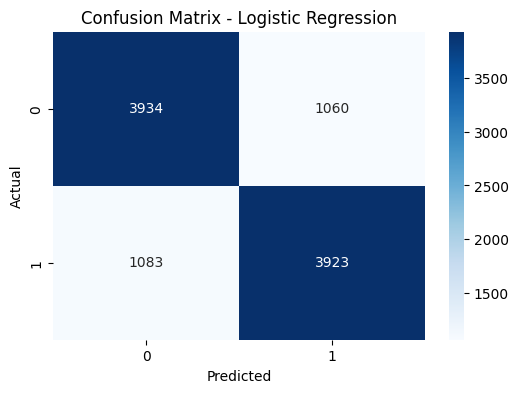

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')

plt.show()